# MNIST Anomaly detection - Tutorial notebook

Source: https://benjoe.medium.com/anomaly-detection-using-pytorch-autoencoder-and-mnist-31c5c2186329

### 1. Setting up libraries

In [11]:
import numpy as np
import pandas as pd
import random
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, losses
from tensorflow.keras.models import Model
from keras.datasets import mnist

import torch
import time

import torch.nn as nn
import seaborn as sns
from collections import defaultdict
from datetime import timedelta

In [12]:
(x_train, _), (x_test, _) = mnist.load_data()

x_train = x_train.astype('float32') / 255.
x_test = x_test.astype('float32') / 255.

x_train = np.reshape(x_train, (len(x_train), 28, 28, 1))
x_test = np.reshape(x_test, (len(x_test), 28, 28, 1))

print(x_train.shape)
print(x_test.shape)

(60000, 28, 28, 1)
(10000, 28, 28, 1)


### 2. Set up clean and create toy "anomalous" data from x_test

Motivation: Idea is that we will be adding artificial noise to the anom data, specifically the indices 0 - 999 data points from x_train. This will be our anomalous data used for loss evaluatiuon later on.

In [13]:
# Reduce dimensionality and flatten the images to give single pixel values.
original = x_test.copy()  # save clean copies before noise modifies the view
anom = x_test[:1000].reshape(1000, -1)
clean = x_test[1000:].reshape(x_test[1000:].shape[0], -1)


print(anom.shape)
for i in range(len(anom)):
    # select row from anom
    row = anom[i]
    # iterate through each element in row
    for i in range(len(row)-1):
        # add noise scaled to [0,1] pixel range
        row[i+1] = min(1.0, row[i+1] + random.randint(10, 200) / 255.0)

(1000, 784)


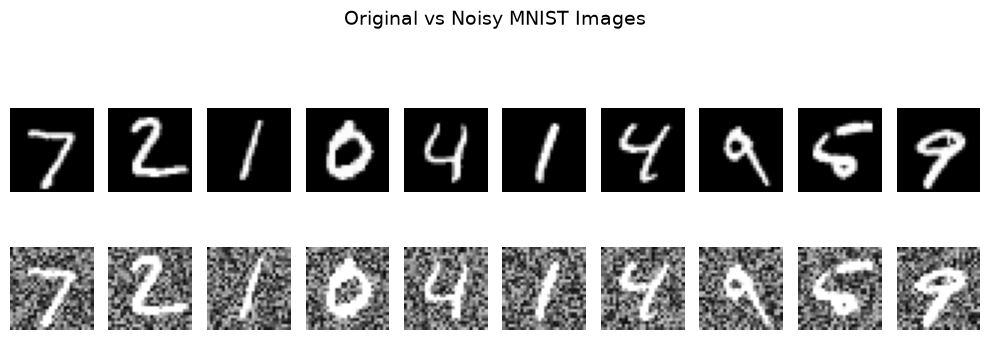

In [14]:
n = 10  # number of examples to display

fig, axes = plt.subplots(2, n, figsize=(10, 4))

for i in range(n):
    axes[0, i].imshow(original[i].reshape(28, 28), cmap='gray')
    axes[0, i].axis('off')

    axes[1, i].imshow(anom[i].reshape(28, 28), cmap='gray')
    axes[1, i].axis('off')

axes[0, 0].set_ylabel('Original', fontsize=12)
axes[1, 0].set_ylabel('Noisy', fontsize=12)

plt.suptitle('Original vs Noisy MNIST Images', fontsize=14)
plt.tight_layout()
plt.show()

### 3. Concatenate, shuffle, and save the dataset

In [15]:
# Convert numpy arrays to DataFrames and attach labels
anom_df = pd.DataFrame(anom)
anom_df['label'] = 1  # anomalous

clean_df = pd.DataFrame(clean)
clean_df['label'] = 0  # clean

# Concatenate, shuffle, and save
an_test = pd.concat([anom_df, clean_df])
an_test = an_test.sample(frac=1).reset_index(drop=True)
an_test.to_csv('anom.csv', index=False)

print(an_test.shape)
print(an_test['label'].value_counts())

(10000, 785)
label
0    9000
1    1000
Name: count, dtype: int64


### 4. Linear compression 

In [16]:
import torch.nn as nn

class AE(nn.Module):
    """Fully-connected autoencoder: 784 -> 16 -> 784.

    The 16-unit bottleneck is a 49x compression of the image, so the network
    cannot memorise its inputs; it has to learn the shared structure of MNIST
    digits and spend its 16 numbers on where a given digit sits within it.
    """
    def __init__(self):
        super(AE, self).__init__()
        self.enc = nn.Sequential(
            nn.Linear(784, 512),
            nn.ReLU(),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 16),
            nn.ReLU()
        )
        self.dec = nn.Sequential(
            nn.Linear(16, 32),
            nn.ReLU(),
            nn.Linear(32, 64),
            nn.ReLU(),
            nn.Linear(64, 128),
            nn.ReLU(),
            nn.Linear(128, 256),
            nn.ReLU(),
            nn.Linear(256, 512),
            nn.ReLU(),
            nn.Linear(512, 784),
            # Sigmoid on the output layer, not ReLU. ReLU has zero gradient for
            # negative pre-activations, so an output unit pushed negative can
            # never recover -- that collapses the decoder to a constant image.
            # Sigmoid is bounded to [0, 1], matching the normalised pixel range.
            nn.Sigmoid()
        )

    def forward(self, x):
        encode = self.enc(x)
        decode = self.dec(encode)
        return decode

In [17]:
batch_size = 32
lr = 1e-3         # learning rate (Adam; 1e-2 with plain SGD was enough to kill the ReLUs)
w_d = 1e-5        # weight decay
epochs = 20

### 5. Training

In [18]:
from torch.utils.data import DataLoader

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Flatten x_train to (60000, 784) and wrap in a DataLoader.
# Note we train on the CLEAN training images only -- the model never sees an
# anomaly. That is the whole premise: learn to reconstruct normality, then treat
# "hard to reconstruct" as "abnormal".
x_train_flat = x_train.reshape(len(x_train), -1)
train_tensor = torch.tensor(x_train_flat, dtype=torch.float32)
train_ = DataLoader(train_tensor, batch_size=batch_size, shuffle=True)

model = AE().to(device)
criterion = nn.MSELoss(reduction='mean')
optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=w_d)

metrics = defaultdict(list)

model.train()
start = time.time()
for epoch in range(epochs):
    ep_start = time.time()
    running_loss = 0.0
    for bx, data in enumerate(train_):
        data = data.to(device)
        sample = model(data)
        loss = criterion(data, sample)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    # running_loss is a sum of per-batch MEAN losses, so divide by the number of
    # BATCHES to recover the true per-pixel MSE. Dividing by len(train_tensor)
    # (the number of samples) understates it by a factor of batch_size, which
    # makes the training loss look ~32x better than the evaluation loss.
    epoch_loss = running_loss / len(train_)
    metrics['train_loss'].append(epoch_loss)
    ep_end = time.time()
    print('-----------------------------------------------')
    print('[EPOCH] {}/{}\n[LOSS] {:.6f}'.format(epoch+1, epochs, epoch_loss))
    print('Epoch Complete in {}'.format(timedelta(seconds=ep_end-ep_start)))
end = time.time()
print('-----------------------------------------------')
print('[System Complete: {}]'.format(timedelta(seconds=end-start)))

-----------------------------------------------
[EPOCH] 1/20
[LOSS] 0.057291
Epoch Complete in 0:01:00.168076
-----------------------------------------------
[EPOCH] 2/20
[LOSS] 0.045391
Epoch Complete in 0:02:14.862126
-----------------------------------------------
[EPOCH] 3/20
[LOSS] 0.042899
Epoch Complete in 0:01:42.089866
-----------------------------------------------
[EPOCH] 4/20
[LOSS] 0.042425
Epoch Complete in 0:01:05.638472
-----------------------------------------------
[EPOCH] 5/20
[LOSS] 0.036894
Epoch Complete in 0:01:18.850062
-----------------------------------------------
[EPOCH] 6/20
[LOSS] 0.035004
Epoch Complete in 0:01:30.617698
-----------------------------------------------
[EPOCH] 7/20
[LOSS] 0.034120
Epoch Complete in 0:02:01.841601
-----------------------------------------------
[EPOCH] 8/20
[LOSS] 0.033550
Epoch Complete in 0:01:08.950563
-----------------------------------------------
[EPOCH] 9/20
[LOSS] 0.032848
Epoch Complete in 0:01:07.631943
----------

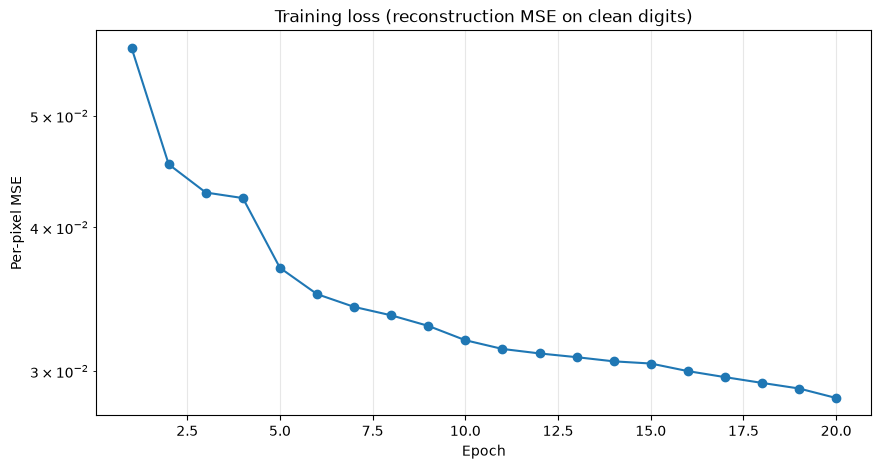

first epoch: 0.05729   final epoch: 0.02843


In [19]:
_, ax = plt.subplots(1, 1, figsize=(10, 5))
ax.set_title('Training loss (reconstruction MSE on clean digits)')
ax.plot(range(1, epochs + 1), metrics['train_loss'], marker='o')
ax.set_xlabel('Epoch')
ax.set_ylabel('Per-pixel MSE')
ax.set_yscale('log')   # log scale: most of the improvement is in the first few epochs
ax.grid(alpha=0.3)
plt.show()

print(f"first epoch: {metrics['train_loss'][0]:.5f}   final epoch: {metrics['train_loss'][-1]:.5f}")

#### 5b. Sanity check: what does the autoencoder actually reconstruct?

The training loss alone can hide a collapsed model (a decoder that emits the same constant blob for every input still reports a plausible-looking MSE). The only way to be sure the bottleneck learned something is to look at the reconstructions.

**Rows 1–2, clean digits and their reconstructions:** recognisable, if blurry. The model has seen 60,000 examples of exactly this, so its 16 latent numbers are enough to say *which* digit it is and roughly how it was drawn.

**Rows 3–4, noisy anomalies and their reconstructions:** note that the model does **not** denoise them back into the original digit. It returns a blurry `8`-like shape for almost every one. That is not a bug — it is the whole mechanism, and it is worth understanding:

- The noisy images lie far outside the training distribution. The noise is random and unstructured, so there is nothing in it for the encoder to latch onto, and it maps essentially *all* of them to the same uninformative point in the 16-d latent space.
- Fed a latent code carrying no digit identity, the decoder's error-minimising output is the **dataset mean** — the average of all 60k training digits. And the mean MNIST digit looks like a blurry 8: it is the union of every stroke position, and 8 overlaps most of them.
- So the model is not drawing eights. It is drawing "generic digit", and generic digit looks like an eight.

Contrast this with the collapsed model in the original notebook, which emitted a constant blob for *every* input, in-distribution or not. This model reconstructs clean digits faithfully and only falls back to the mean for inputs it cannot express. That is exactly the property anomaly detection relies on.

The takeaway: the anomaly score is **not** "how much noise was added". It is **distance from the learned manifold of digits** — the size of the part of the image that the 16-d latent space cannot translate.

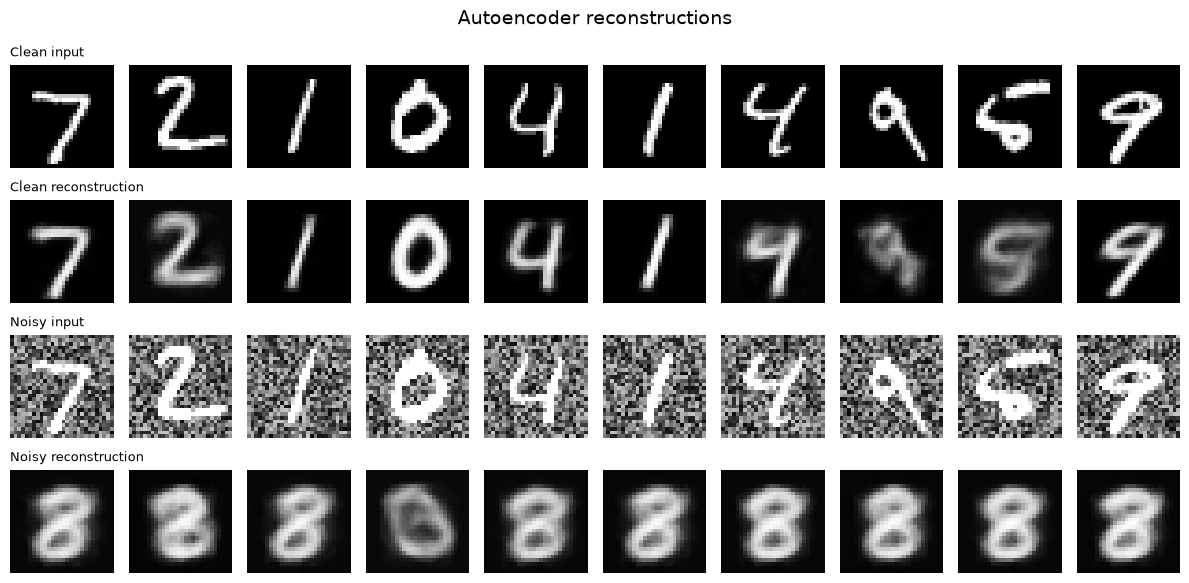

clean  MSE (these 10): mean 0.0274
noisy  MSE (these 10): mean 0.1652


In [20]:
model.eval()

n = 10
clean_in = torch.tensor(original[:n].reshape(n, -1), dtype=torch.float32).to(device)
anom_in = torch.tensor(anom[:n], dtype=torch.float32).to(device)

with torch.no_grad():
    clean_out = model(clean_in).cpu().numpy()
    anom_out = model(anom_in).cpu().numpy()

rows = [
    (clean_in.cpu().numpy(), 'Clean input'),
    (clean_out, 'Clean reconstruction'),
    (anom.copy()[:n], 'Noisy input'),
    (anom_out, 'Noisy reconstruction'),
]

fig, axes = plt.subplots(4, n, figsize=(12, 6))
for r, (imgs, title) in enumerate(rows):
    for c in range(n):
        axes[r, c].imshow(imgs[c].reshape(28, 28), cmap='gray', vmin=0, vmax=1)
        axes[r, c].axis('off')
    axes[r, 0].set_title(title, fontsize=9, loc='left')

plt.suptitle('Autoencoder reconstructions', fontsize=14)
plt.tight_layout()
plt.show()

# Per-image reconstruction error for these two handfuls, for scale
clean_mse = ((clean_in.cpu().numpy() - clean_out) ** 2).mean(axis=1)
anom_mse = ((anom[:n] - anom_out) ** 2).mean(axis=1)
print(f'clean  MSE (these {n}): mean {clean_mse.mean():.4f}')
print(f'noisy  MSE (these {n}): mean {anom_mse.mean():.4f}')

Latent-code spread across images (mean std over the 16 dims):
  clean inputs : 2.5842
  noisy inputs : 0.5550   <- 4.7x smaller
  A small spread means the encoder is returning the same code regardless of
  which digit it was shown: the digit identity has been destroyed.

Noisy reconstructions vs the mean training digit:
  RMS distance from the dataset mean image : 0.2192
  RMS spread among the reconstructions      : 0.0625
  Both small => every noisy image decodes to roughly the same thing, and that
  thing is roughly the average MNIST digit.


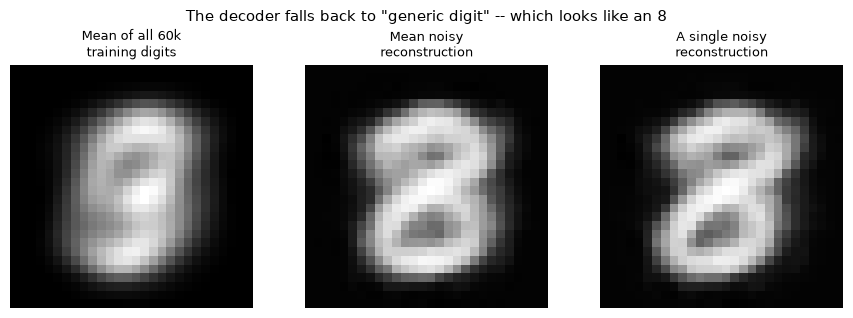

In [23]:
# Why do the noisy reconstructions all look like the same blurry 8?
# Two testable claims:
#   (1) the encoder maps every noisy image to nearly the SAME latent code
#   (2) the decoder then emits nearly the DATASET MEAN, which looks like an 8

n_probe = 500
clean_probe = torch.tensor(original[:n_probe].reshape(n_probe, -1), dtype=torch.float32).to(device)
anom_probe = torch.tensor(anom[:n_probe], dtype=torch.float32).to(device)

with torch.no_grad():
    z_clean = model.enc(clean_probe).cpu().numpy()      # (n, 16) latent codes
    z_anom = model.enc(anom_probe).cpu().numpy()
    recon_anom = model.dec(model.enc(anom_probe)).cpu().numpy()

# (1) How much do the latent codes vary from image to image?
#     Averaged over the 16 latent dims, the std ACROSS images.
spread_clean = z_clean.std(axis=0).mean()
spread_anom = z_anom.std(axis=0).mean()
print('Latent-code spread across images (mean std over the 16 dims):')
print(f'  clean inputs : {spread_clean:.4f}')
print(f'  noisy inputs : {spread_anom:.4f}   <- {spread_clean / max(spread_anom, 1e-9):.1f}x smaller')
print('  A small spread means the encoder is returning the same code regardless of')
print('  which digit it was shown: the digit identity has been destroyed.')
print()

# (2) Are the noisy reconstructions just the dataset mean?
mean_train_img = x_train_flat.mean(axis=0)                     # the average of all 60k digits
dist_to_mean = np.sqrt(((recon_anom - mean_train_img) ** 2).mean(axis=1)).mean()
dist_between = np.sqrt(((recon_anom - recon_anom.mean(axis=0)) ** 2).mean(axis=1)).mean()
print('Noisy reconstructions vs the mean training digit:')
print(f'  RMS distance from the dataset mean image : {dist_to_mean:.4f}')
print(f'  RMS spread among the reconstructions      : {dist_between:.4f}')
print('  Both small => every noisy image decodes to roughly the same thing, and that')
print('  thing is roughly the average MNIST digit.')

fig, axes = plt.subplots(1, 3, figsize=(9, 3.2))
axes[0].imshow(mean_train_img.reshape(28, 28), cmap='gray')
axes[0].set_title('Mean of all 60k\ntraining digits', fontsize=9)
axes[1].imshow(recon_anom.mean(axis=0).reshape(28, 28), cmap='gray')
axes[1].set_title('Mean noisy\nreconstruction', fontsize=9)
axes[2].imshow(recon_anom[0].reshape(28, 28), cmap='gray')
axes[2].set_title('A single noisy\nreconstruction', fontsize=9)
for a in axes:
    a.axis('off')
plt.suptitle('The decoder falls back to "generic digit" -- which looks like an 8', fontsize=11)
plt.tight_layout()
plt.show()

### 6. Loss evaluation

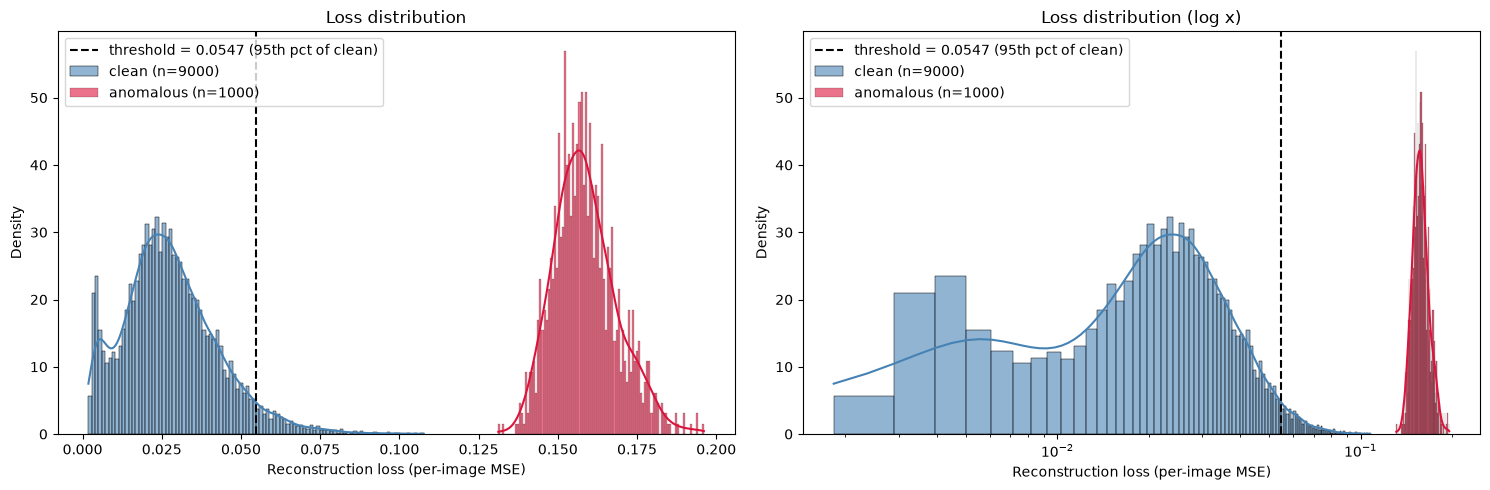

Threshold                : 0.0547
Clean      loss: median 0.0262   mean 0.0278
Anomalous  loss: median 0.1577   mean 0.1587
Separation (median ratio): 6.0x


In [21]:
model.eval()

with torch.no_grad():
    pixel_data = an_test.drop(columns=[c for c in ['label', 'loss'] if c in an_test.columns])
    test_tensor = torch.tensor(pixel_data.values, dtype=torch.float32).to(device)
    reconstructed = model(test_tensor)
    # mean over pixels (dim=1) but NOT over images -> one anomaly score per image
    loss_dist = ((test_tensor - reconstructed) ** 2).mean(dim=1).cpu().numpy()

labels = an_test['label'].values
clean_losses = loss_dist[labels == 0]
anom_losses = loss_dist[labels == 1]

# 95th percentile of the CLEAN losses -> a 5% false-positive rate by construction.
# In a real search you would set this from simulation/sideband data, never from
# the anomalies themselves, which you are not supposed to have labels for.
upper_threshold = float(np.percentile(clean_losses, 95))

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

for ax, logx in zip(axes, [False, True]):
    sns.histplot(clean_losses, bins=100, stat='density', color='steelblue',
                 label=f'clean (n={len(clean_losses)})', kde=True, ax=ax, alpha=0.6)
    sns.histplot(anom_losses, bins=100, stat='density', color='crimson',
                 label=f'anomalous (n={len(anom_losses)})', kde=True, ax=ax, alpha=0.6)
    ax.axvline(upper_threshold, color='k', ls='--',
               label=f'threshold = {upper_threshold:.4f} (95th pct of clean)')
    ax.set_xlabel('Reconstruction loss (per-image MSE)')
    ax.legend()
    if logx:
        ax.set_xscale('log')
        ax.set_title('Loss distribution (log x)')
    else:
        ax.set_title('Loss distribution')

plt.tight_layout()
plt.show()

print(f'Threshold                : {upper_threshold:.4f}')
print(f'Clean      loss: median {np.median(clean_losses):.4f}   mean {clean_losses.mean():.4f}')
print(f'Anomalous  loss: median {np.median(anom_losses):.4f}   mean {anom_losses.mean():.4f}')
print(f'Separation (median ratio): {np.median(anom_losses) / np.median(clean_losses):.1f}x')

### 7. ROC curve and detection performance

The loss histogram shows *whether* the two populations separate; the ROC curve quantifies *how well*, at every possible threshold at once.

Sweep the threshold from high to low and, at each value, record the **true positive rate** (fraction of real anomalies caught) against the **false positive rate** (fraction of clean digits wrongly flagged). The curve is the locus of those points. The diagonal is what a coin flip gets you; a curve that hugs the top-left corner means you can catch nearly all the anomalies while flagging almost no clean digits. The **AUC** is the area beneath it, which also has a direct probabilistic reading: it is the probability that a randomly chosen anomaly is assigned a higher loss than a randomly chosen clean digit. AUC = 0.5 is useless, AUC = 1.0 is perfect separation.

The AUC is threshold-free — it summarises the *score*, not any particular cut. The confusion matrix below then reports what actually happens at the specific 95th-percentile threshold chosen above.

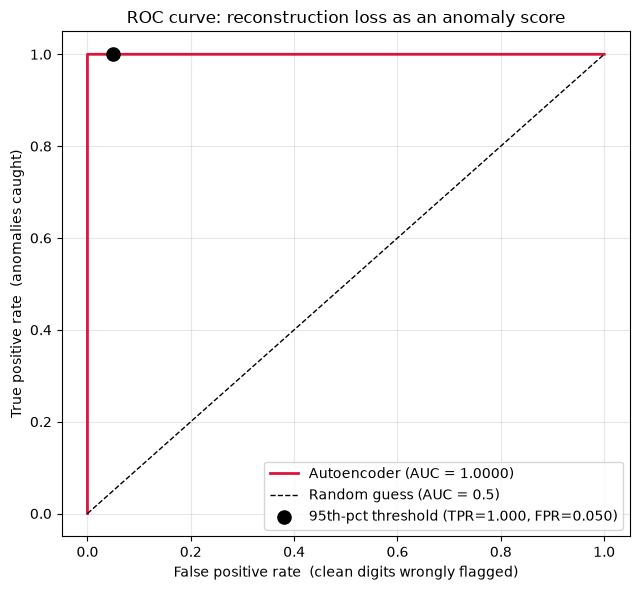

AUC                     : 1.0000

At threshold = 0.0547
  Confusion matrix           predicted clean   predicted anomalous
    actually clean                8550                 450
    actually anomalous               0                1000

  Recall / TPR (anomalies caught)     : 1.0000  (1000/1000)
  FPR (clean wrongly flagged)         : 0.0500  (450/9000)
  Precision (flagged that are real)   : 0.6897
  F1                                  : 0.8163


In [22]:
def roc_curve_np(y_true, scores):
    """ROC curve, in numpy (this env's sklearn has a broken scipy DLL).

    Sort by descending score and sweep the threshold down through every observed
    value; the running counts of hits and false alarms give TPR and FPR.
    """
    order = np.argsort(-scores, kind='mergesort')
    y = y_true[order].astype(float)
    tps = np.cumsum(y)                    # anomalies caught at or above this score
    fps = np.cumsum(1.0 - y)              # clean images wrongly flagged
    n_pos, n_neg = y.sum(), len(y) - y.sum()
    tpr = np.concatenate([[0.0], tps / n_pos])
    fpr = np.concatenate([[0.0], fps / n_neg])
    return fpr, tpr


fpr, tpr = roc_curve_np(labels, loss_dist)
auc = float(np.trapezoid(tpr, fpr))

# Where does our 95th-percentile threshold land on the curve?
pred = (loss_dist > upper_threshold).astype(int)
tp = int(((pred == 1) & (labels == 1)).sum())
fp = int(((pred == 1) & (labels == 0)).sum())
fn = int(((pred == 0) & (labels == 1)).sum())
tn = int(((pred == 0) & (labels == 0)).sum())

recall = tp / (tp + fn)            # a.k.a. TPR, detection efficiency
fallout = fp / (fp + tn)           # a.k.a. FPR, ~0.05 by construction
precision = tp / (tp + fp) if (tp + fp) else 0.0
f1 = 2 * precision * recall / (precision + recall) if (precision + recall) else 0.0

plt.figure(figsize=(6.5, 6))
plt.plot(fpr, tpr, lw=2, color='crimson', label=f'Autoencoder (AUC = {auc:.4f})')
plt.plot([0, 1], [0, 1], 'k--', lw=1, label='Random guess (AUC = 0.5)')
plt.scatter([fallout], [recall], s=90, zorder=5, color='k',
            label=f'95th-pct threshold (TPR={recall:.3f}, FPR={fallout:.3f})')
plt.xlabel('False positive rate  (clean digits wrongly flagged)')
plt.ylabel('True positive rate  (anomalies caught)')
plt.title('ROC curve: reconstruction loss as an anomaly score')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f'AUC                     : {auc:.4f}')
print()
print(f'At threshold = {upper_threshold:.4f}')
print(f'  Confusion matrix           predicted clean   predicted anomalous')
print(f'    actually clean      {tn:>14}      {fp:>14}')
print(f'    actually anomalous  {fn:>14}      {tp:>14}')
print()
print(f'  Recall / TPR (anomalies caught)     : {recall:.4f}  ({tp}/{tp+fn})')
print(f'  FPR (clean wrongly flagged)         : {fallout:.4f}  ({fp}/{fp+tn})')
print(f'  Precision (flagged that are real)   : {precision:.4f}')
print(f'  F1                                  : {f1:.4f}')

### 7b. Why a "perfect" AUC still produced 450 false positives

These two facts are both true and they do not contradict each other:

- **AUC = 1.0** says every anomaly scored higher than every clean digit. Sort all 10,000 images by loss and the 1,000 anomalies sit at the top with no clean digit mixed in. A cut with **zero** errors *exists*.
- **450 clean digits were flagged.** That is the *threshold rule*, not the model. `np.percentile(clean_losses, 95)` flags the top 5% of clean images **by definition** — it returns ~450 false positives out of 9,000 no matter how good the score is. Hand it a flawless score or a random number generator and you still get 450.

We placed the cut inside the clean distribution's own right tail when there was an empty gap further up. On the ROC plot, notice the operating point sits at (0.05, 1.0) — out along the flat top edge, *not* at the top-left corner. The curve already reached TPR = 1.0 back at FPR ≈ 0. We paid a 5% false-positive rate and bought nothing with it.

The cell below measures the gap between the two populations and sweeps the threshold to show what that choice cost.

**The catch:** the zero-error threshold can only be found by peeking at the anomaly losses, and in a real search you have no anomaly labels. What you *can* legitimately do is take a much tighter percentile of the clean (or simulated) distribution — the 99.9th rather than the 95th — which costs nothing in recall when the score separates this cleanly.

In [ ]:
# --- Is there actually a gap between the two populations? ---
max_clean = clean_losses.max()
min_anom = anom_losses.min()
n_overlap = int((clean_losses > min_anom).sum())   # clean digits scoring above the quietest anomaly

print(f'Highest clean loss    : {max_clean:.4f}')
print(f'Lowest  anomaly loss  : {min_anom:.4f}')
if min_anom > max_clean:
    print(f'--> The classes are SEPARABLE. Empty gap of width {min_anom - max_clean:.4f}.')
    print(f'    Any threshold in ({max_clean:.4f}, {min_anom:.4f}) gives 0 FP and 0 FN.')
else:
    print(f'--> The classes OVERLAP: {n_overlap} clean images score above the lowest anomaly.')
    print(f'    No threshold can be perfect; AUC < 1.')
print()


# --- What does the threshold choice actually cost us? ---
def evaluate(thr):
    pred = loss_dist > thr
    tp = int((pred & (labels == 1)).sum())
    fp = int((pred & (labels == 0)).sum())
    fn = int((~pred & (labels == 1)).sum())
    tn = int((~pred & (labels == 0)).sum())
    rec = tp / (tp + fn) if (tp + fn) else 0.0
    fpr_ = fp / (fp + tn) if (fp + tn) else 0.0
    prec = tp / (tp + fp) if (tp + fp) else 0.0
    f1_ = 2 * prec * rec / (prec + rec) if (prec + rec) else 0.0
    return tp, fp, fn, rec, fpr_, prec, f1_


rows = [(f'{p}th pct of clean', float(np.percentile(clean_losses, p)))
        for p in (95, 99, 99.5, 99.9)]
rows.append(('max clean loss', float(max_clean)))
if min_anom > max_clean:
    rows.append(('midpoint of gap', float((max_clean + min_anom) / 2)))

print(f"{'threshold rule':<20} {'value':>8} {'TP':>5} {'FP':>5} {'FN':>4} "
      f"{'recall':>7} {'FPR':>7} {'prec':>7} {'F1':>7}")
print('-' * 80)
for name, thr in rows:
    tp, fp, fn, rec, fpr_, prec, f1_ = evaluate(thr)
    print(f'{name:<20} {thr:>8.4f} {tp:>5} {fp:>5} {fn:>4} '
          f'{rec:>7.3f} {fpr_:>7.4f} {prec:>7.3f} {f1_:>7.3f}')

print()
print('The 95th-percentile rule throws away ~450 clean images for nothing: the score')
print('already ranks every anomaly above every clean digit. Tightening the percentile')
print('keeps recall at 1.0 while collapsing the false positives.')